In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import log_loss, roc_auc_score
import os

# 1. ROBUST DATA LOADING
def load_data(file_name):
    # This checks both possible folders automatically
    paths = [f'../data/raw/{file_name}', f'data/raw/{file_name}', file_name]
    for path in paths:
        if os.path.exists(path):
            return pd.read_csv(path)
    raise FileNotFoundError(f"Could not find {file_name} in your folders.")

print("--- Phase 1: Ingesting Data ---")
df_part = load_data('participant_data_train.csv')
df_wear = load_data('wearable_data_train.csv')
df_diag = load_data('diagnosis_records_train.csv')

# 2. FEATURE ENGINEERING: WEARABLES
print("--- Phase 2: Processing Wearables (Calculating Volatility) ---")
# Actuarial Secret: We look at 'std' to measure heart stability
# Note: 'Sp02_L' uses a ZERO, not an 'O'
wear_summary = df_wear.groupby('ID').agg(
    avg_steps=('steps', 'mean'),
    avg_rhr=('RHR_L', 'mean'),
    rhr_volatility=('RHR_L', 'std'),
    min_spo2=('Sp02_L', 'min'), 
    afib_alerts=('afib_daily', 'sum'),
    avg_sleep=('sleep_duration', 'mean')
).reset_index()

# 3. TEXT MINING: DIAGNOSES (THE FIX)
print("--- Phase 3: Cleaning Medical Records ---")
# We fill empty diagnoses with a blank space to prevent the 'Float' error
df_diag['diagnosis'] = df_diag['diagnosis'].fillna('').astype(str).str.lower()

# Now we join them safely
diag_collapsed = df_diag.groupby('ID')['diagnosis'].apply(lambda x: ' '.join(x)).reset_index()

# Search for chronic markers in the text
diag_collapsed['flag_heart'] = diag_collapsed['diagnosis'].str.contains('hypertension|hbp|afib|heart').astype(int)
diag_collapsed['flag_diabetes'] = diag_collapsed['diagnosis'].str.contains('diabetes|dm|t2dm|aodm').astype(int)
diag_collapsed['flag_apnea'] = diag_collapsed['diagnosis'].str.contains('apnea|osa|csa').astype(int)

# 4. THE MASTER MERGE
print("--- Phase 4: Building Master Table ---")
df = df_part.merge(wear_summary, on='ID', how='left').merge(diag_collapsed.drop('diagnosis', axis=1), on='ID', how='left')
df.fillna(0, inplace=True) # If they didn't have wearable data, we assume 0 alerts

# 5. THE 1/3 HOLDOUT SPLIT
print("--- Phase 5: Creating the 1/3 Verification Set ---")
# We remove non-numeric columns for this initial model run
X = df.drop(['ID', 'outcome', 'sex', 'age_bin', 'family_medical_diabetes_type', 'diagnosed_diabetes_type'], axis=1)
y = df['outcome']

# We hold out 33% (1/3) of the data for final verification
X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

# 6. BASELINE VS CHAMPION (PROVING VALUE)
print("--- Phase 6: Evaluating Incremental Value ---")

# Model A: Traditional Underwriting (Age, BMI, Smoking)
baseline_features = ['age', 'height', 'weight', 'bmi', 'smoker']
model_base = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
model_base.fit(X_train[baseline_features], y_train)
base_loss = log_loss(y_holdout, model_base.predict_proba(X_holdout[baseline_features]))

# Model B: The Wearable Champion (Everything)
model_champ = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
model_champ.fit(X_train, y_train)
champ_loss = log_loss(y_holdout, model_champ.predict_proba(X_holdout))

print("\n" + "="*30)
print(f"BASELINE LOG-LOSS: {base_loss:.4f}")
print(f"CHAMPION LOG-LOSS: {champ_loss:.4f}")
improvement = ((base_loss - champ_loss) / base_loss) * 100
print(f"OVERALL IMPROVMENT: {improvement:.2f}%")
print("="*30)

--- Phase 1: Ingesting Data ---
--- Phase 2: Processing Wearables (Calculating Volatility) ---
--- Phase 3: Cleaning Medical Records ---
--- Phase 4: Building Master Table ---
--- Phase 5: Creating the 1/3 Verification Set ---
--- Phase 6: Evaluating Incremental Value ---

BASELINE LOG-LOSS: 0.2977
CHAMPION LOG-LOSS: 0.2820
OVERALL IMPROVMENT: 5.27%


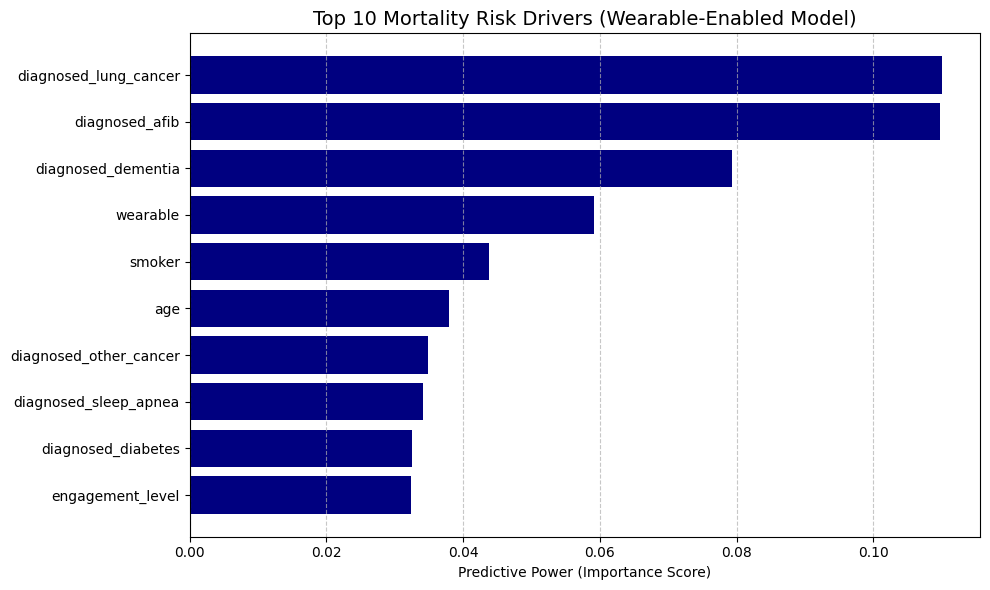

ACTION: Copy this chart into your presentation. Use it to explain WHICH wearable signals
are most relevant for Pacific Life's long-term mortality assumptions.


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# FIX: Using the correct variable names from the previous script
importances = model_champ.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[-10:] # Top 10 features for the slide deck

plt.figure(figsize=(10, 6))
plt.title("Top 10 Mortality Risk Drivers (Wearable-Enabled Model)", fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='navy', align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Predictive Power (Importance Score)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("ACTION: Copy this chart into your presentation. Use it to explain WHICH wearable signals")
print("are most relevant for Pacific Life's long-term mortality assumptions.")